STATISTIICAL ANALYSIS

Kepler Exoplanet Search Results

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, f_oneway, pointbiserialr
import warnings
import os
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)
BASE = r'C:\Users\adity\Desktop\Kepler-Exoplanet Project'

LOAD THE DATASET


In [11]:
df = pd.read_csv(os.path.join(BASE, 'data', 'kepler_clean.csv'))
TARGET = 'koi_disposition'

KEY_FEATURES = ['koi_period', 'koi_prad', 'koi_teq',
                'koi_insol', 'koi_model_snr', 'koi_steff',
                'koi_slogg', 'koi_srad', 'koi_score',
                'koi_depth', 'koi_duration', 'koi_impact']

confirmed = df[df[TARGET] == 'CONFIRMED']
false_pos = df[df[TARGET] == 'FALSE POSITIVE']
candidate = df[df[TARGET] == 'CANDIDATE']

print("=" * 60)
print("PHASE 2 - STATISTICAL ANALYSIS")
print("=" * 60)
print(f"CONFIRMED: {len(confirmed):,}")
print(f"FALSE POSITIVE: {len(false_pos):,}")
print(f"CANDIDATE: {len(candidate):,}")

PHASE 2 - STATISTICAL ANALYSIS
CONFIRMED: 2,281
FALSE POSITIVE: 3,922
CANDIDATE: 1,792


GROUP SUMMARY STATISTICS

In [12]:
print("Per-class summary statistics")
summary = df.groupby(TARGET)[KEY_FEATURES].agg(['mean', 'median', 'std'])
print(summary)

print("T-Test: CONFIRMED vs FALSE POSITIVE")
print(f"{'Feature':<20} {'Confirmed Mean':>15} {'FP Mean':>12} {'p-value':>12} {'Significant':>14}")
print("-" * 75)

ttest_results = []
for col in KEY_FEATURES:
    a = confirmed[col].dropna()
    b = false_pos[col].dropna()
    stat, p = ttest_ind(a, b, equal_var=False)
    sig = 'YES' if p < 0.05 else 'NO'
    ttest_results.append({'Feature': col, 'Confirmed_Mean':a.mean(),
                          'FP_Mean': b.mean(), 'p_value': p, 'Significant': p<0.05})
    print(f"{col:<20} {a.mean():>15.3f} {b.mean():>12.3f} {p:>12.6f} {sig:>14}")

ttest_df = pd.DataFrame(ttest_results).sort_values('p_value')


Per-class summary statistics
                koi_period                  koi_prad                   \
                      mean  median      std     mean  median      std   
koi_disposition                                                         
CANDIDATE          43.7865 10.2746  87.2418   6.5109  1.7500  40.5892   
CONFIRMED          26.5702 11.2540  51.2623   2.8718  2.1700   3.3663   
FALSE POSITIVE     40.1951  4.0222 101.0768  52.2716 16.8650 443.4269   

                  koi_teq                      koi_insol  ... koi_score  \
                     mean    median       std       mean  ...       std   
koi_disposition                                           ...             
CANDIDATE        941.0195  830.0000  680.6273  6379.2020  ...    0.1826   
CONFIRMED        840.2679  782.0000  386.5597   351.6759  ...    0.1445   
FALSE POSITIVE  1409.3983 1232.5000 1009.2564 13440.2737  ...    0.0626   

                 koi_depth                      koi_duration                \
   

ANOVA-ALL THREE CLASSES

In [13]:
print("ANOVA: All three cases")
print(f"{'Feature':>20} {'F-statistic':>14} {'p_value':>12} {'Significant':>14}")
print("=" * 60)

for col in KEY_FEATURES:
  a = confirmed[col].dropna()
  b = false_pos[col].dropna()
  c = candidate[col].dropna()
  fstat, p = f_oneway(a, b, c)
  sig = 'YES' if p < 0.05 else 'NO'
  print(f"{col:<20} {fstat:>14.3f} {p:>12.6f} {sig:>14}")

ANOVA: All three cases
             Feature    F-statistic      p_value    Significant
koi_period                   24.813     0.000000            YES
koi_prad                     23.638     0.000000            YES
koi_teq                     433.686     0.000000            YES
koi_insol                     4.455     0.011652            YES
koi_model_snr               311.372     0.000000            YES
koi_steff                   175.055     0.000000            YES
koi_slogg                   102.122     0.000000            YES
koi_srad                     21.112     0.000000            YES
koi_score                 55248.728     0.000000            YES
koi_depth                   397.425     0.000000            YES
koi_duration                107.044     0.000000            YES
koi_impact                  196.916     0.000000            YES


CORRELATION ANALYSIS

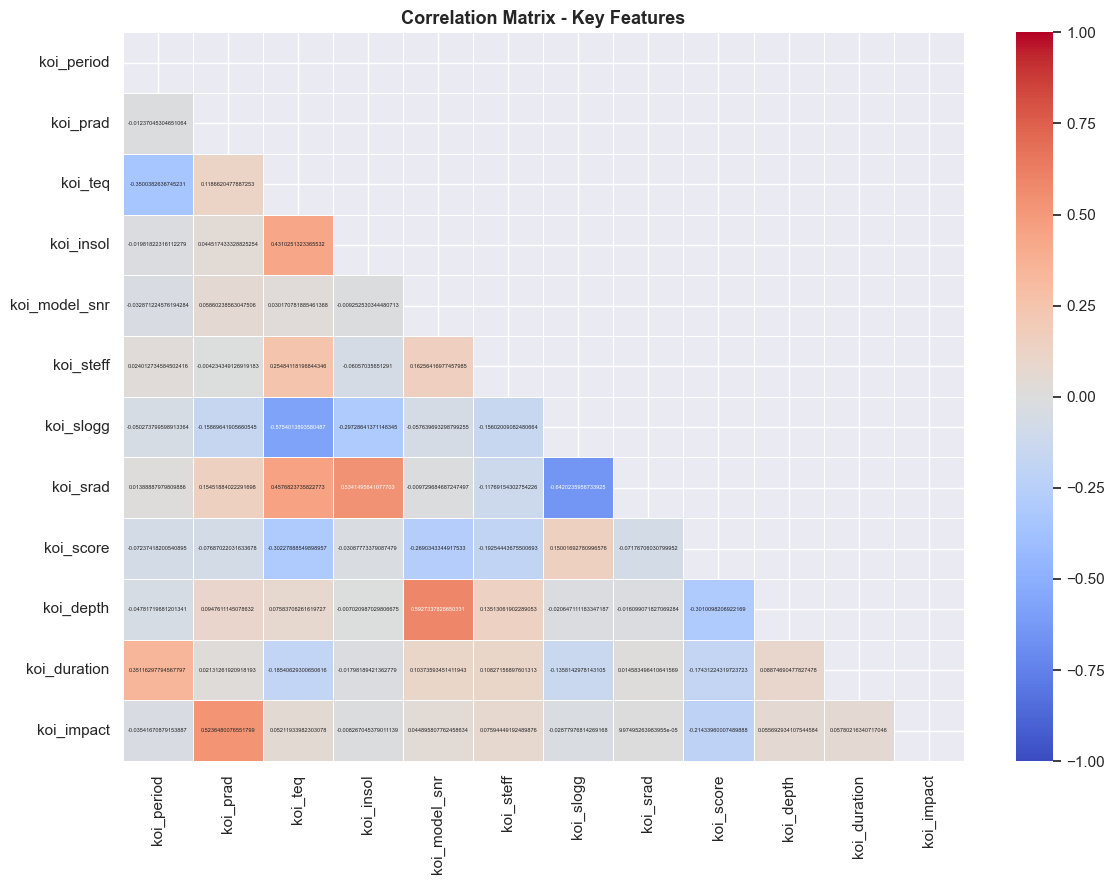

In [14]:
numeric_df = df[KEY_FEATURES].dropna()
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='10', cmap='coolwarm',
    center=0, linewidth=0.5, ax=ax,
    annot_kws={'size': 4}, vmin=-1, vmax=1
)
ax.set_title('Correlation Matrix - Key Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'outputs', 'p2_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

OUTLIER DETECTION - IQR METHOD

In [15]:
print("Outlier counts per feature (IQR method)")
print(f"{'feature':<20} {'Outliers':>10} {'Outlier %':>12}")
print("="*45)

for col in KEY_FEATURES:
  series = df[col].dropna()
  Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
  IQR = Q3 - Q1
  outliers = ((series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)).sum()
  pct = outliers / len(series) * 100
  print(f"{col:<20} {outliers:>10,} {pct:>11.2f}%")

Outlier counts per feature (IQR method)
feature                Outliers    Outlier %
koi_period                1,090       13.63%
koi_prad                  1,026       12.83%
koi_teq                     353        4.42%
koi_insol                 1,205       15.07%
koi_model_snr             1,421       17.77%
koi_steff                   490        6.13%
koi_slogg                   550        6.88%
koi_srad                    850       10.63%
koi_score                     0        0.00%
koi_depth                 1,645       20.58%
koi_duration                643        8.04%
koi_impact                   53        0.66%


VIOLIN PLOTS - CLASS COMPARISON

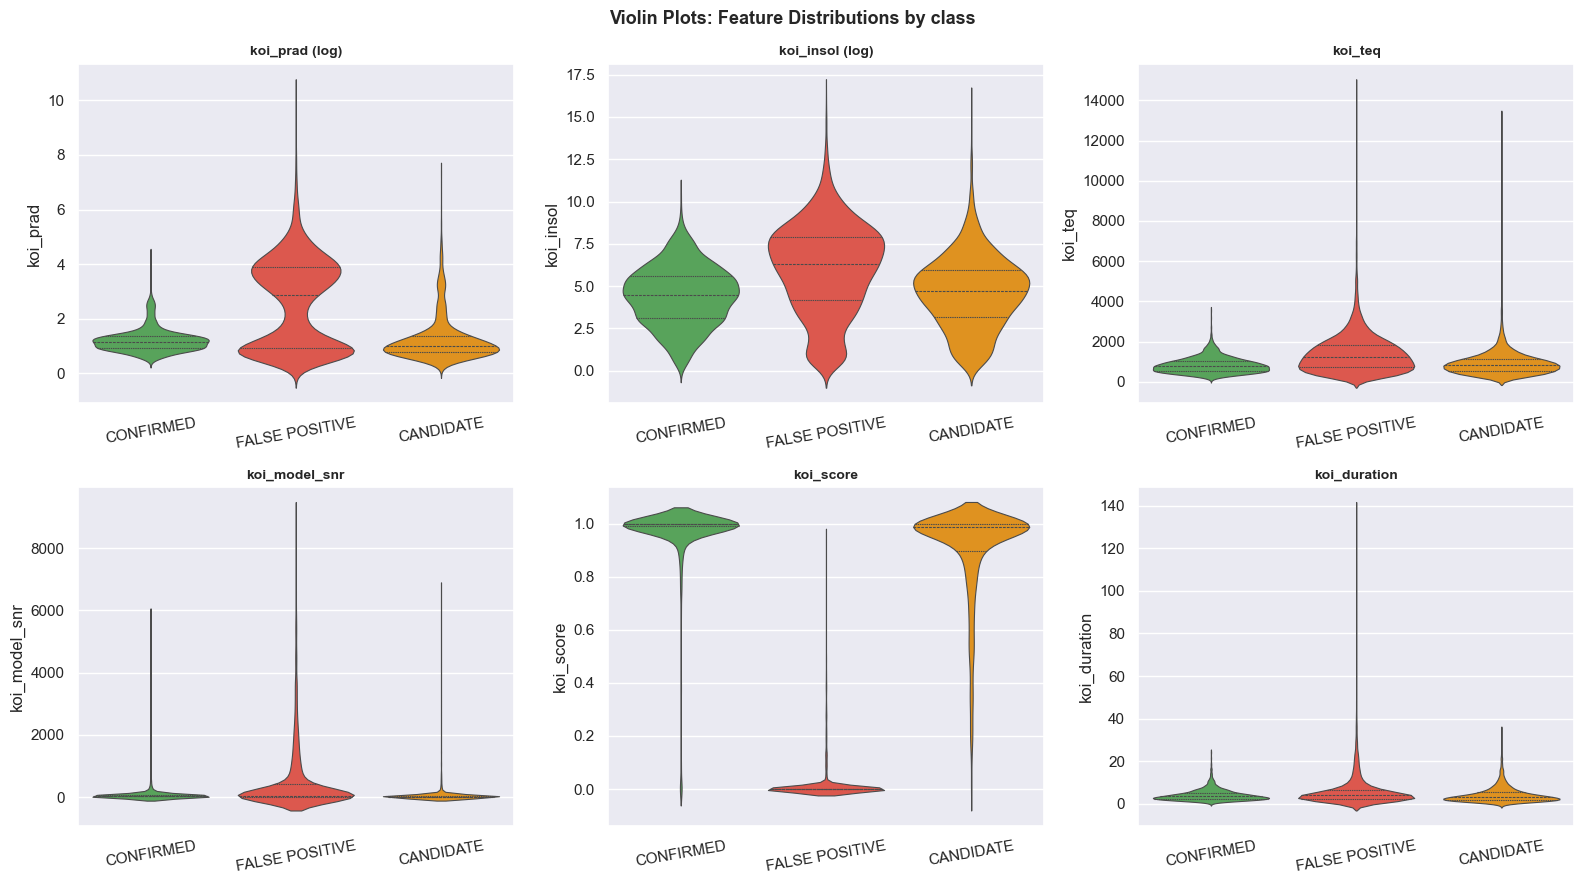

In [16]:
palette = {'CONFIRMED': '#4CAF50', 'FALSE POSITIVE': '#F44336', 'CANDIDATE': '#FF9800'}
order = ['CONFIRMED', 'FALSE POSITIVE', 'CANDIDATE']

fig, axes = plt.subplots(2, 3, figsize=(16,9))
axes = axes.flatten()

violin_features = ['koi_prad', 'koi_insol', 'koi_teq',
                   'koi_model_snr', 'koi_score', 'koi_duration']

for i, col in enumerate(violin_features):
  ax = axes[i]
  plot_data = df[[TARGET, col]].dropna()
  if col in ['koi_prad', 'koi_insol', 'koi_depth']:
    plot_data = plot_data.copy()
    plot_data[col] = np.log1p(plot_data[col])
    title = f'{col} (log)'
  else:
    title = col
  sns.violinplot(data=plot_data, x=TARGET, y=col, palette=palette, order=order,
                 ax=ax, inner='quartile', linewidth=0.8)
  ax.set_title(title, fontsize=10, fontweight='bold')
  ax.set_xlabel('')
  ax.tick_params(axis='x', rotation=10)
plt.suptitle('Violin Plots: Feature Distributions by class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'outputs', 'p1_violin_plots.png'), dpi=150, bbox_inches='tight')
plt.show()

CORRELATION WITH TARGET

BINARY: CONFIRMED=1; FP=0

Point-biseral correlation with target (CONFIRMED vs FALSE POSITIVE)
feature               Correlation      p-value
--------------------------------------------------
koi_period                -0.0760     0.000000
koi_prad                  -0.0674     0.000000
koi_teq                   -0.3119     0.000000
koi_insol                 -0.0376     0.003088
koi_model_snr             -0.2252     0.000000
koi_steff                 -0.2182     0.000000
koi_slogg                  0.1714     0.000000
koi_srad                  -0.0814     0.000000
koi_score                  0.9766     0.000000
koi_depth                 -0.2615     0.000000
koi_duration              -0.1485     0.000000
koi_impact                -0.2081     0.000000


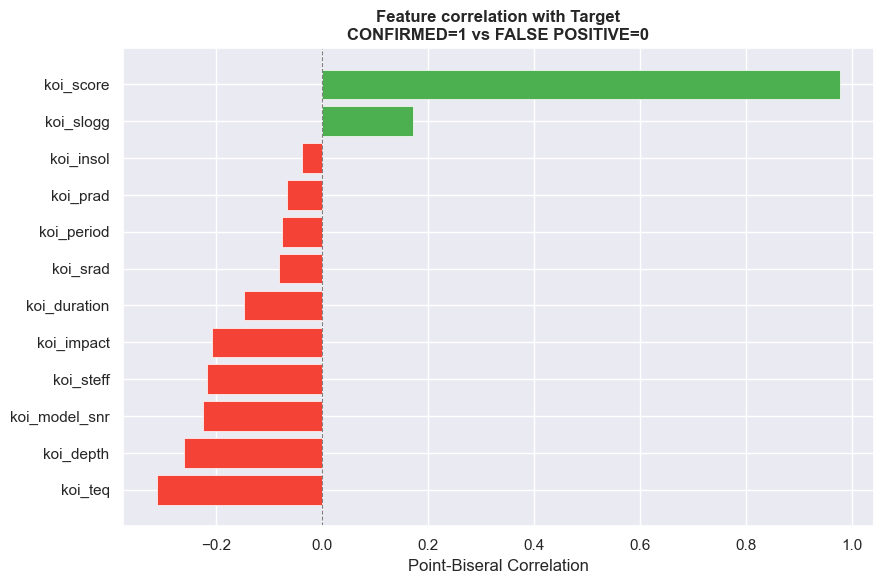

In [17]:
print("Point-biseral correlation with target (CONFIRMED vs FALSE POSITIVE)")
binary_df = df[df[TARGET].isin(['CONFIRMED', 'FALSE POSITIVE'])].copy()
binary_df['target_binary'] = (binary_df[TARGET] == 'CONFIRMED').astype(int)

print(f"{'feature':<20} {'Correlation':>12} {'p-value':>12}")
print("-"*50)

corr_results = []
for col in KEY_FEATURES:
  sub = binary_df[[col, 'target_binary']].dropna()
  r, p = pointbiserialr(sub['target_binary'], sub[col])
  corr_results.append((col, r, p))
  print(f"{col:<20} {r:>12.4f} {p:>12.6f}")

#Plot correlation bar chart
corr_df = pd.DataFrame(corr_results, columns=['Feature', 'Correlation', 'p_value'])
corr_df = corr_df.sort_values('Correlation')
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#4CAF50' if x > 0 else '#F44336' for x in corr_df['Correlation']]
ax.barh(corr_df['Feature'], corr_df['Correlation'], color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('Feature correlation with Target\nCONFIRMED=1 vs FALSE POSITIVE=0', fontsize=12, fontweight='bold')
ax.set_xlabel('Point-Biseral Correlation')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'outputs', 'p2_target_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()